In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import wordcloud,STOPWORDS,ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor
import warnings as wrg
wrg.filterwarnings("ignore")


In [13]:
ig = pd.read_csv(r"C:\Users\BCS\Downloads\Instagram data.csv",encoding='latin 1')
ig.head(5)

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [14]:
ig.isnull().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [15]:
ig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


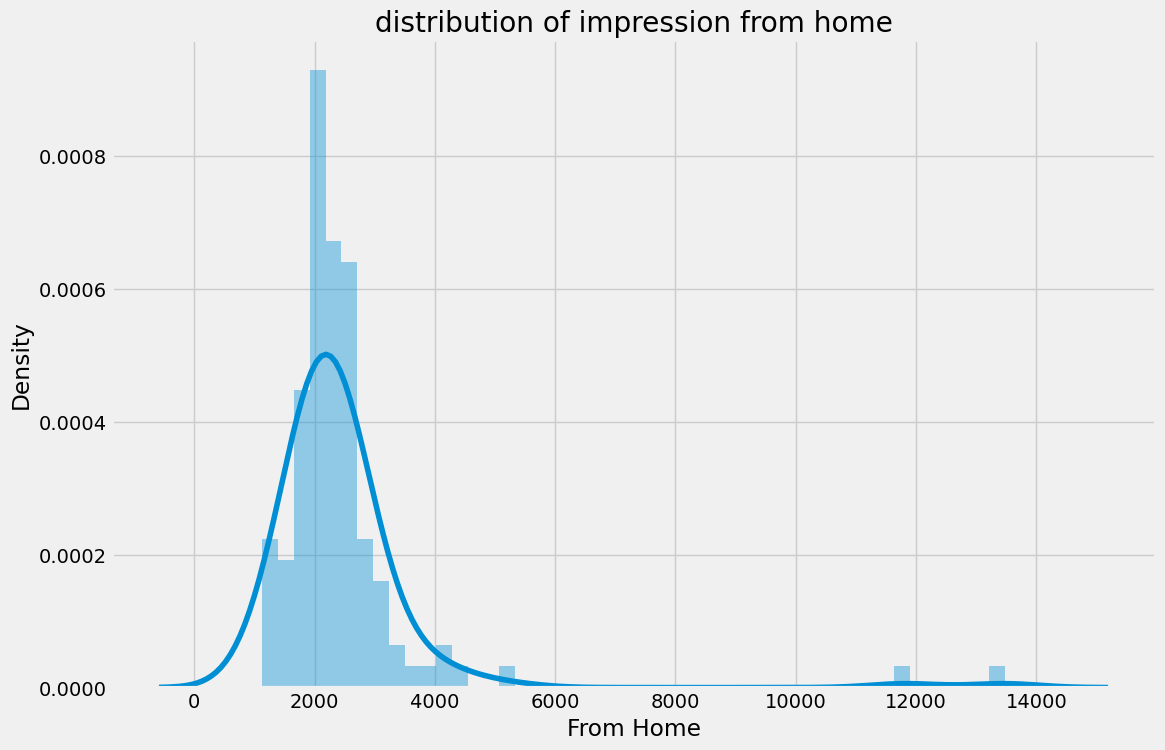

In [21]:
plt.figure(figsize=(12,8))
plt.style.use('fivethirtyeight')
plt.title("distribution of impression from home")
sns.distplot(ig['From Home'])
plt.show()

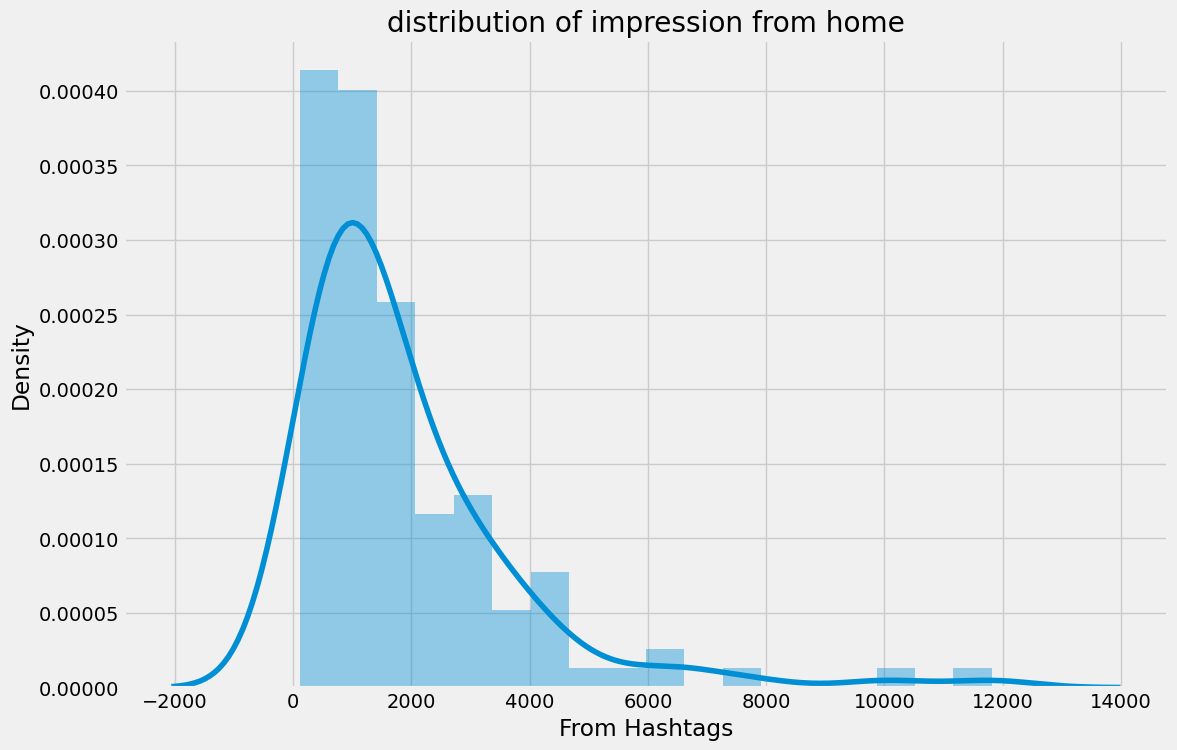

In [22]:
plt.figure(figsize=(12,8))
#plt.style.use('fivethirtyeight')
plt.title("distribution of impression from hastags")
sns.distplot(ig['From Hashtags'])
plt.show()

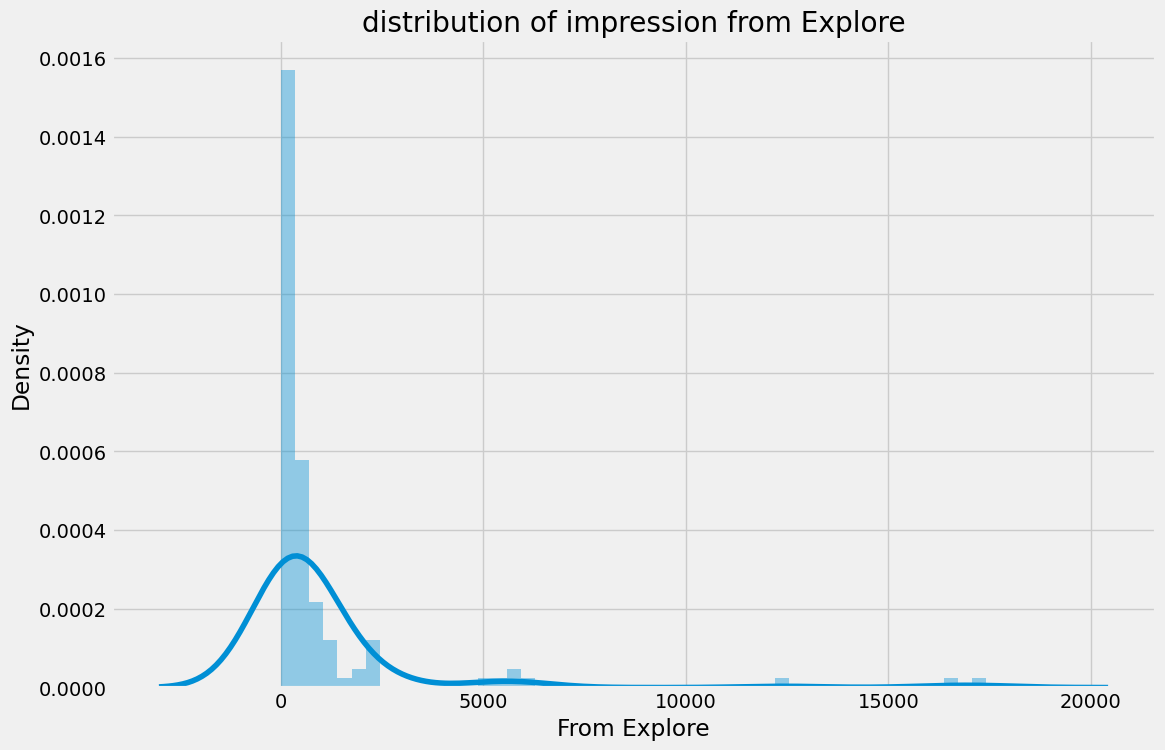

In [24]:
plt.figure(figsize=(12,8))
#plt.style.use('fivethirtyeight')
plt.title("distribution of impression from Explore")
sns.distplot(ig['From Explore'])
plt.show()

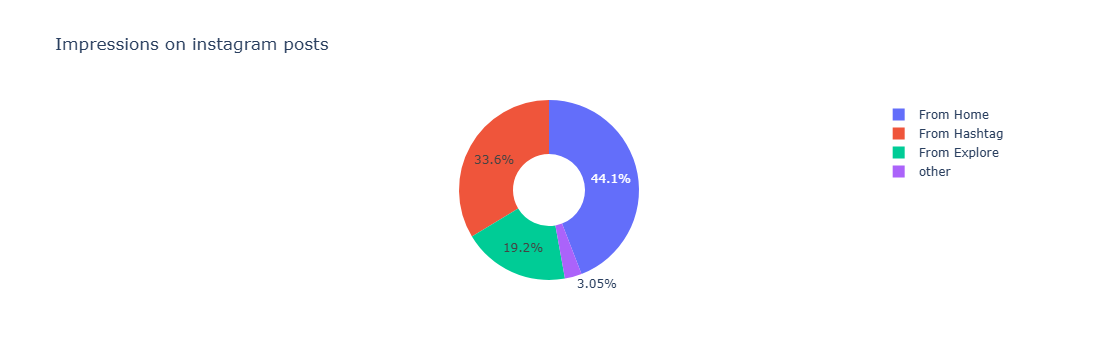

In [28]:
home = ig['From Home'].sum()
hastag = ig['From Hashtags'].sum()
explore = ig['From Explore'].sum()
other = ig['From Other'].sum()
labels = ['From Home','From Hashtag','From Explore','other']
varlues = [home,hastag,explore,other]
fig = px.pie(ig,values=varlues,names=labels,hole=0.4,title='Impressions on instagram posts')
fig.show()

In [38]:
text = " ".join(i for i in ig.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords,background_color='white').generate(text)
plt.style.use('classic')
plt.figure(figsize=(12,10))
plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis("off")
plt.show()

NameError: name 'WordCloud' is not defined

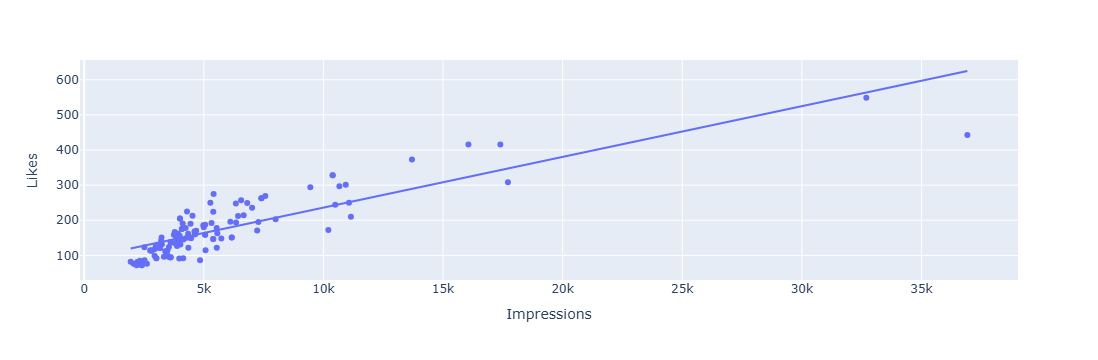

In [36]:
figure = px.scatter(data_frame=ig,x='Impressions',y='Likes',trendline='ols')
figure.show()

In [48]:
ig['Impressions'] = ig['Impressions'].astype(int)
print(ig.dtypes)

Impressions        int64
From Home          int64
From Hashtags      int64
From Explore       int64
From Other         int64
Saves              int64
Comments           int64
Shares             int64
Likes              int64
Profile Visits     int64
Follows            int64
Caption           object
Hashtags          object
dtype: object


In [50]:
numeric_df = ig.select_dtypes(include=['int64','float64'])
correlation = numeric_df.corr()
print(correlation["Impressions"].sort_values(ascending=False))

Impressions       1.000000
From Explore      0.893607
Follows           0.889363
Likes             0.849835
From Home         0.844698
Saves             0.779231
Profile Visits    0.760981
Shares            0.634675
From Other        0.592960
From Hashtags     0.560760
Comments         -0.028524
Name: Impressions, dtype: float64


In [51]:
conversion_rate = (ig['Follows'].sum()/ ig['Profile Visits'].sum())*100
print(conversion_rate)

41.00265604249668


In [55]:
x = np.array(ig[['Likes','Saves','Comments','Shares','Profile Visits','Follows']])
y = np.array(ig[['Impressions']])
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=42)
model = PassiveAggressiveRegressor()
model.fit(xtrain,ytrain)
model.score(xtest,ytest)

0.879081912035216